## DSN Bootcamp Qualification Hackathon — ML Track
**Goal:** Predict total_sales for each product-store row using product and store attributes.
**Approach:** Understand → Analyse → Clean → Engineer → Model → Predict.

BY: ZAINAB SALMAN

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()

Train shape: (6818, 13)
Test shape: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## Exploratory Data Analysis $ Data Cleaning
Two key issues were found: `product_category` had ~48 inconsistent case variants of 16 real
categories (fixed via normalization), and `store_size` was missing for 3 entire stores (not
random rows) — treated as its own "Missing" category rather than guessed.
`product_weight_kg` was imputed using each product's own recorded weight from other rows
(justified by low within-product variance), falling back to category average, then global average.

In [2]:
print("--- TRAIN DTYPES ---")
print(train.dtypes)
print()
print("--- MISSING VALUES: TRAIN ---")
print(train.isnull().sum())
print()
print("--- MISSING VALUES: TEST ---")
print(test.isnull().sum())

--- TRAIN DTYPES ---
id                      object
product_code            object
product_weight_kg      float64
fat_content             object
shelf_visibility       float64
product_category        object
product_price          float64
store_code              object
store_age_years          int64
store_size              object
store_location_tier     object
store_format            object
total_sales            float64
dtype: object

--- MISSING VALUES: TRAIN ---
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

--- MISSING VALUES: TEST ---
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility

In [3]:
print("--- % MISSING: TRAIN ---")
print((train.isnull().sum() / len(train) * 100).round(1))
print()
print("--- % MISSING: TEST ---")
print((test.isnull().sum() / len(test) * 100).round(1))

--- % MISSING: TRAIN ---
id                      0.0
product_code            0.0
product_weight_kg      18.0
fat_content             0.0
shelf_visibility        0.0
product_category        0.0
product_price           0.0
store_code              0.0
store_age_years         0.0
store_size             28.1
store_location_tier     0.0
store_format            0.0
total_sales             0.0
dtype: float64

--- % MISSING: TEST ---
id                      0.0
product_code            0.0
product_weight_kg      17.9
fat_content             0.0
shelf_visibility        0.0
product_category        0.0
product_price           0.0
store_code              0.0
store_age_years         0.0
store_size             28.8
store_location_tier     0.0
store_format            0.0
dtype: float64


In [4]:
store_size_by_store = train.groupby('store_code')['store_size'].agg(lambda x: x.dropna().unique())
print(store_size_by_store)

store_code
STORE-7WS    [Medium]
STORE-89Z    [Medium]
STORE-9RG     [Small]
STORE-AGY     [Large]
STORE-DKU          []
STORE-HL7    [Medium]
STORE-JOR          []
STORE-OYG          []
STORE-T5G     [Small]
STORE-YLW     [Small]
Name: store_size, dtype: object


In [5]:
print("Unique products in train:", train['product_code'].nunique())
print("Total rows in train:", len(train))
print()
print(train['product_code'].value_counts().describe())

Unique products in train: 1555
Total rows in train: 6818

count    1555.000000
mean        4.384566
std         1.556328
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: count, dtype: float64


In [6]:
# For products with more than one recorded weight, how much does the weight vary?
weight_variation = train.dropna(subset=['product_weight_kg']).groupby('product_code')['product_weight_kg'].std()

print(weight_variation.describe())
print()
print("Products with a recorded std of exactly 0 (perfectly consistent):", (weight_variation == 0).sum())
print("Products with NaN std (only 1 recorded weight, nothing to compare):", weight_variation.isnull().sum())

count    1454.000000
mean        0.204086
std         0.125688
min         0.000000
25%         0.109692
50%         0.183916
75%         0.276493
max         0.753069
Name: product_weight_kg, dtype: float64

Products with a recorded std of exactly 0 (perfectly consistent): 1
Products with NaN std (only 1 recorded weight, nothing to compare): 93


In [7]:
# Does any product have ZERO recorded weight across all its rows (not just this one row)?
products_with_any_weight = train.dropna(subset=['product_weight_kg'])['product_code'].unique()
all_products = train['product_code'].unique()

products_with_no_weight_at_all = set(all_products) - set(products_with_any_weight)
print("Products with NO recorded weight anywhere in train:", len(products_with_no_weight_at_all))

Products with NO recorded weight anywhere in train: 8


In [8]:
# Combine train + test FEATURES ONLY
combined = pd.concat([train.drop(columns=['total_sales']), test], ignore_index=True)

# Level 1: average weight per product_code (across all rows, train+test, where known)
product_weight_map = combined.groupby('product_code')['product_weight_kg'].mean()

# Level 3 safety net: overall average weight
global_weight_mean = combined['product_weight_kg'].mean()

print("product_weight_map covers", product_weight_map.notnull().sum(), "products")
print("global_weight_mean:", global_weight_mean)

product_weight_map covers 1555 products
global_weight_mean: 12.85389402173913


In [9]:
print("Raw unique category values:", train['product_category'].nunique())
print()
print(train['product_category'].value_counts())

Raw unique category values: 48

product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92
soft drinks               88
meat                      88
Others                 

In [10]:
def normalize_category(s):
    # Step 1: strip whitespace, lowercase everything, then title-case it
    s = s.str.strip().str.lower().str.title()
    # Step 2: .title() capitalizes "and" too (-> "Fruits And Vegetables") - fix that back to lowercase "and"
    s = s.str.replace(' And ', ' and ', regex=False)
    return s

normalized = normalize_category(train['product_category'])
print("Unique categories after normalization:", normalized.nunique())
print()
print(normalized.value_counts())

Unique categories after normalization: 16

product_category
Fruits and Vegetables    1006
Snack Foods               933
Household                 740
Frozen Foods              675
Dairy                     554
Canned                    517
Baking Goods              516
Health and Hygiene        412
Soft Drinks               366
Meat                      339
Breads                    209
Hard Drinks               169
Others                    132
Starchy Foods             113
Breakfast                  85
Seafood                    52
Name: count, dtype: int64


In [11]:
# Apply the same normalization to the combined data, so category-based lookups are built on clean labels
combined['product_category'] = normalize_category(combined['product_category'])

# Level 2: average weight per (clean) product_category, across train+test combined
category_weight_map = combined.groupby('product_category')['product_weight_kg'].mean()

print(category_weight_map.sort_values())

product_category
Breads                   11.301910
Hard Drinks              11.387956
Soft Drinks              11.819404
Baking Goods             12.284231
Canned                   12.341363
Seafood                  12.510640
Meat                     12.821540
Breakfast                12.838022
Frozen Foods             12.848539
Snack Foods              12.995958
Health and Hygiene       13.095685
Fruits and Vegetables    13.238302
Household                13.359916
Dairy                    13.427856
Starchy Foods            13.695944
Others                   13.865015
Name: product_weight_kg, dtype: float64


In [12]:
print(train['shelf_visibility'].describe())
print()
print("Rows with shelf_visibility == 0:", (train['shelf_visibility'] == 0).sum())
print("As a percentage:", round((train['shelf_visibility'] == 0).mean() * 100, 2), "%")

count    6818.000000
mean        0.065527
std         0.051566
min         0.000000
25%         0.026600
50%         0.053200
75%         0.093400
max         0.320100
Name: shelf_visibility, dtype: float64

Rows with shelf_visibility == 0: 422
As a percentage: 6.19 %


In [13]:
zero_vis = train[train['shelf_visibility'] == 0]
nonzero_vis = train[train['shelf_visibility'] != 0]

print("Total sales when shelf_visibility == 0:")
print(zero_vis['total_sales'].describe())
print()
print("Total sales when shelf_visibility != 0:")
print(nonzero_vis['total_sales'].describe())

Total sales when shelf_visibility == 0:
count     422.000000
mean     2154.615664
std      1624.750889
min        33.300000
25%       888.747500
50%      1727.960000
75%      3117.660000
max      8009.520000
Name: total_sales, dtype: float64

Total sales when shelf_visibility != 0:
count     6396.000000
mean      2176.085446
std       1702.723989
min         32.700000
25%        831.735000
50%       1792.855000
75%       3092.212500
max      12996.820000
Name: total_sales, dtype: float64


In [14]:
def normalize_category(s):
    s = s.str.strip().str.lower().str.title()
    s = s.str.replace(' And ', ' and ', regex=False)
    return s

# Build lookup maps once, from train+test features combined
combined = pd.concat([train.drop(columns=['total_sales']), test], ignore_index=True)
combined['product_category'] = normalize_category(combined['product_category'])

product_weight_map = combined.groupby('product_code')['product_weight_kg'].mean()
category_weight_map = combined.groupby('product_category')['product_weight_kg'].mean()
global_weight_mean = combined['product_weight_kg'].mean()

def clean(df):
    df = df.copy()
    df['product_category'] = normalize_category(df['product_category'])

    df['product_weight_kg'] = df['product_weight_kg'].fillna(df['product_code'].map(product_weight_map))
    df['product_weight_kg'] = df['product_weight_kg'].fillna(df['product_category'].map(category_weight_map))
    df['product_weight_kg'] = df['product_weight_kg'].fillna(global_weight_mean)

    df['store_size'] = df['store_size'].fillna('Missing')
    df['zero_visibility'] = (df['shelf_visibility'] == 0).astype(int)

    return df

train_clean = clean(train)
test_clean = clean(test)

print("Missing weight remaining:", train_clean['product_weight_kg'].isnull().sum(), test_clean['product_weight_kg'].isnull().sum())
print("Missing store_size remaining:", train_clean['store_size'].isnull().sum(), test_clean['store_size'].isnull().sum())

Missing weight remaining: 0 0
Missing store_size remaining: 0 0


In [15]:
print("Average total_sales by store_format:")
print(train_clean.groupby('store_format')['total_sales'].mean().sort_values(ascending=False))
print()
print("Average total_sales by store_size:")
print(train_clean.groupby('store_size')['total_sales'].mean().sort_values(ascending=False))
print()
print("Average total_sales by store_location_tier:")
print(train_clean.groupby('store_location_tier')['total_sales'].mean().sort_values(ascending=False))

Average total_sales by store_format:
store_format
Flagship Hypermarket    3660.182219
Standard Supermarket    2316.319677
Superstore              1971.661954
Corner Shop              336.353868
Name: total_sales, dtype: float64

Average total_sales by store_size:
store_size
Medium     2670.506826
Large      2254.890120
Small      1918.405954
Missing    1828.749171
Name: total_sales, dtype: float64

Average total_sales by store_location_tier:
store_location_tier
Tier_2    2341.795296
Tier_3    2254.114400
Tier_1    1868.171278
Name: total_sales, dtype: float64


In [16]:
print("Average total_sales by product_category:")
print(train_clean.groupby('product_category')['total_sales'].mean().sort_values(ascending=False))
print()
print("Correlation of numeric columns with total_sales:")
print(train_clean[['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']].corr()['total_sales'].sort_values(ascending=False))

Average total_sales by product_category:
product_category
Starchy Foods            2407.718584
Household                2292.464662
Fruits and Vegetables    2277.854672
Meat                     2264.310383
Seafood                  2262.524231
Dairy                    2238.317076
Snack Foods              2223.830568
Canned                   2196.398743
Hard Drinks              2189.723195
Breads                   2186.152871
Frozen Foods             2140.770133
Health and Hygiene       1996.266044
Soft Drinks              1967.399454
Others                   1947.435833
Baking Goods             1943.416860
Breakfast                1852.197765
Name: total_sales, dtype: float64

Correlation of numeric columns with total_sales:
total_sales          1.000000
product_price        0.569833
store_age_years      0.039443
product_weight_kg    0.013624
shelf_visibility    -0.118124
Name: total_sales, dtype: float64


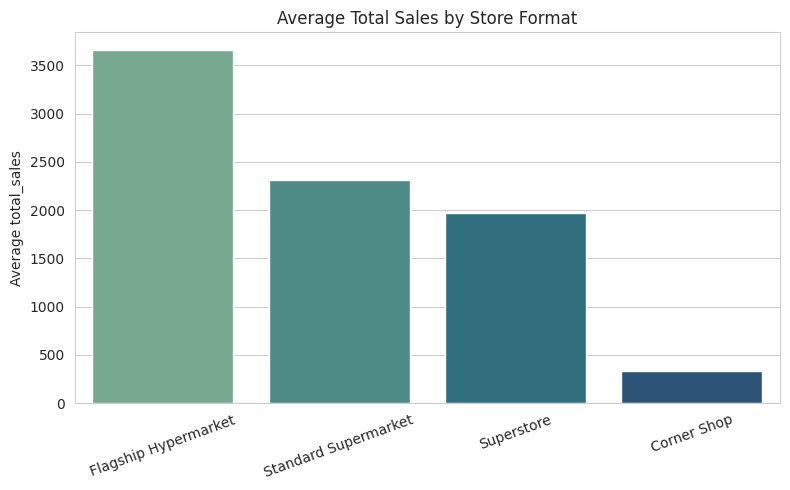

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

format_sales = train_clean.groupby('store_format')['total_sales'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=format_sales, x='store_format', y='total_sales', hue='store_format', palette='crest', legend=False)
plt.title('Average Total Sales by Store Format')
plt.ylabel('Average total_sales')
plt.xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

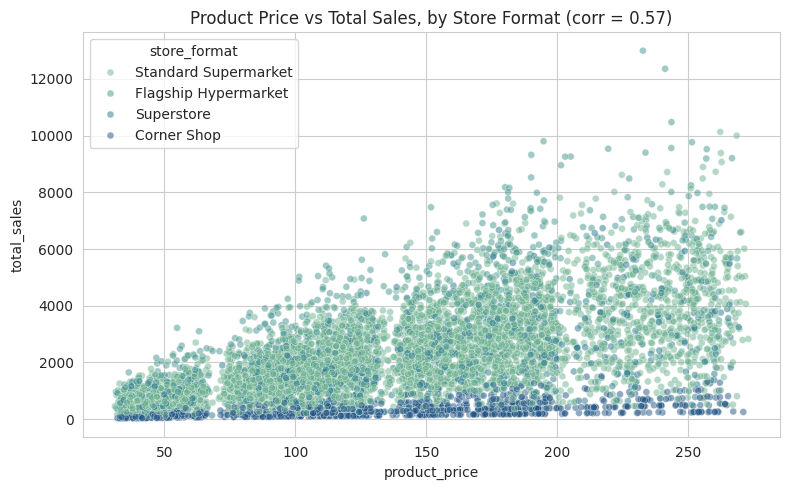

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=train_clean, x='product_price', y='total_sales', hue='store_format', alpha=0.5, s=25, palette='crest')
plt.title('Product Price vs Total Sales, by Store Format (corr = 0.57)')
plt.tight_layout()
plt.show()

In [19]:
print("Average total_sales by fat_content:")
print(train_clean.groupby('fat_content')['total_sales'].mean().sort_values(ascending=False))
print()
print("Row counts per fat_content (so we know if any group is tiny/unreliable):")
print(train_clean['fat_content'].value_counts())

Average total_sales by fat_content:
fat_content
Regular    2218.379323
Low Fat    2151.165785
Name: total_sales, dtype: float64

Row counts per fat_content (so we know if any group is tiny/unreliable):
fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64


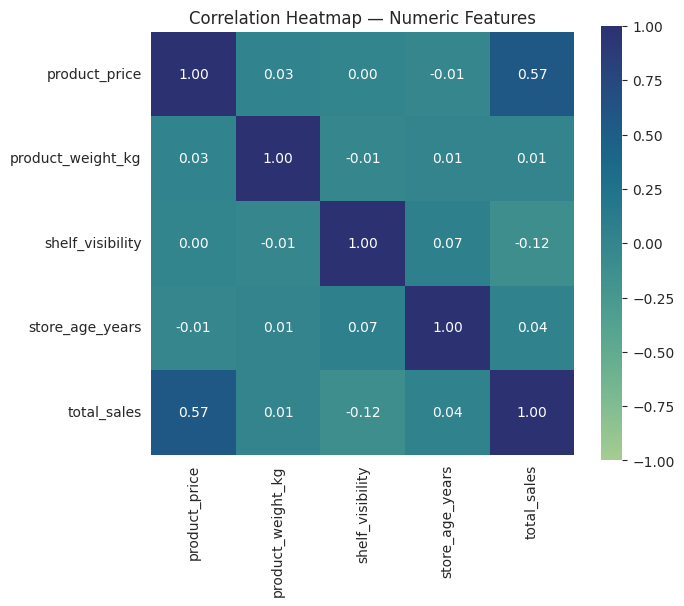

In [20]:
numeric_cols = ['product_price', 'product_weight_kg', 'shelf_visibility', 'store_age_years', 'total_sales']
corr_matrix = train_clean[numeric_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='crest', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## Feature Engineering
EDA showed `store_format` and `product_price` are the strongest sales drivers, and a scatter plot
revealed price's effect on sales differs by store format (steep for Flagship Hypermarkets, flat for
Corner Shops). This motivated `price_relative_to_format`. K-fold target encoding was also added for
`product_code` and `store_code` to capture product/store-level popularity without leaking the target.

In [21]:
# Average price per store_format, computed from train+test combined (feature-only, no leakage)
format_price_map = combined.groupby('store_format')['product_price'].mean()

def engineer(df):
    df = df.copy()
    df['format_avg_price'] = df['store_format'].map(format_price_map)
    df['price_relative_to_format'] = df['product_price'] / df['format_avg_price']
    return df

train_final = engineer(train_clean)
test_final = engineer(test_clean)

print(train_final[['product_price', 'store_format', 'format_avg_price', 'price_relative_to_format']].head())

   product_price          store_format  format_avg_price  \
0          81.37  Standard Supermarket        141.203972   
1          42.05  Standard Supermarket        141.203972   
2          41.35  Standard Supermarket        141.203972   
3         174.35  Flagship Hypermarket        139.763176   
4         203.06  Standard Supermarket        141.203972   

   price_relative_to_format  
0                  0.576259  
1                  0.297796  
2                  0.292839  
3                  1.247467  
4                  1.438062  


## Modeling
Ridge (linear baseline), Random Forest, and Gradient Boosting were compared via 5-fold CV.
Gradient Boosting performed best; hyperparameter tuning (RandomizedSearchCV) further improved it.
A 50/50 blend of tuned Random Forest and Gradient Boosting gave the best, most stable CV RMSE (~1076).

In [22]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
num_features = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',
                 'zero_visibility', 'price_relative_to_format']
cat_features = ['fat_content', 'product_category', 'store_code', 'store_size',
                'store_location_tier', 'store_format']

X = train_final[num_features + cat_features]
y = train_final['total_sales']
X_test = test_final[num_features + cat_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
], remainder='passthrough')

models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=500, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.03, subsample=0.8, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    rmses = []
    for tr_idx, val_idx in kf.split(X):
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = pipe.predict(X.iloc[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[val_idx], preds)))
    print(f'{name:20s} RMSE = {np.mean(rmses):8.2f}  (+/- {np.std(rmses):.2f})')

Ridge                RMSE =  1130.22  (+/- 23.79)
RandomForest         RMSE =  1089.33  (+/- 19.77)
GradientBoosting     RMSE =  1084.93  (+/- 19.31)


In [24]:
from sklearn.base import clone

rmses = []
for tr_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    p_rf = Pipeline([('prep', preprocessor), ('model', clone(models['RandomForest']))])
    p_gb = Pipeline([('prep', preprocessor), ('model', clone(models['GradientBoosting']))])
    p_rf.fit(X_tr, y_tr)
    p_gb.fit(X_tr, y_tr)

    blend_preds = 0.5 * p_rf.predict(X_val) + 0.5 * p_gb.predict(X_val)
    rmses.append(np.sqrt(mean_squared_error(y_val, blend_preds)))

print(f'Blend (RF+GBR): RMSE = {np.mean(rmses):.2f} (+/- {np.std(rmses):.2f})')

Blend (RF+GBR): RMSE = 1084.06 (+/- 19.34)


In [25]:
def kfold_target_encode(train_df, test_df, col, target_col, n_splits=5, smoothing=10):
    global_mean = train_df[target_col].mean()
    train_encoded = pd.Series(index=train_df.index, dtype='float64')

    kf_enc = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in kf_enc.split(train_df):
        fold_train = train_df.iloc[tr_idx]
        stats = fold_train.groupby(col)[target_col].agg(['mean', 'count'])
        # smoothing: blend product's own mean with global mean, weighted by how many rows it has
        smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        train_encoded.iloc[val_idx] = train_df.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

    # For test set: use ALL of train (no folds needed, since test never leaks into itself)
    full_stats = train_df.groupby(col)[target_col].agg(['mean', 'count'])
    full_smoothed = (full_stats['mean'] * full_stats['count'] + global_mean * smoothing) / (full_stats['count'] + smoothing)
    test_encoded = test_df[col].map(full_smoothed).fillna(global_mean)

    return train_encoded, test_encoded

train_encoded, test_encoded = kfold_target_encode(train_final, test_final, 'product_code', 'total_sales')

train_final['product_avg_sales'] = train_encoded
test_final['product_avg_sales'] = test_encoded

print(train_final[['product_code', 'total_sales', 'product_avg_sales']].head(10))

  product_code  total_sales  product_avg_sales
0   PRD-PRFP9S      1764.98        1985.581980
1   PRD-PXXK71       342.13        1968.201311
2   PRD-V5MOIJ       378.85        1664.163981
3   PRD-UN5Z3J      5595.72        2389.684158
4   PRD-6RDQYB      2375.36        2120.080441
5   PRD-E6VA05       842.75        1667.619696
6   PRD-MHLD93      4512.70        2186.663981
7   PRD-EF6Y39      2373.55        2297.889716
8   PRD-IAZMTU      2037.05        2081.057978
9   PRD-DH2TA3       213.93        2099.172340


In [ ]:
num_features = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',
                 'zero_visibility', 'price_relative_to_format', 'product_avg_sales']
cat_features = ['fat_content', 'product_category', 'store_code', 'store_size',
                'store_location_tier', 'store_format']

X = train_final[num_features + cat_features]
y = train_final['total_sales']
X_test = test_final[num_features + cat_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
], remainder='passthrough')

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    rmses = []
    for tr_idx, val_idx in kf.split(X):
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = pipe.predict(X.iloc[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[val_idx], preds)))
    print(f'{name:20s} RMSE = {np.mean(rmses):8.2f}  (+/- {np.std(rmses):.2f})')

Ridge                RMSE =  1130.43  (+/- 23.61)


In [ ]:
rmses = []
for tr_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    p_rf = Pipeline([('prep', preprocessor), ('model', clone(models['RandomForest']))])
    p_gb = Pipeline([('prep', preprocessor), ('model', clone(models['GradientBoosting']))])
    p_rf.fit(X_tr, y_tr)
    p_gb.fit(X_tr, y_tr)

    blend_preds = 0.5 * p_rf.predict(X_val) + 0.5 * p_gb.predict(X_val)
    rmses.append(np.sqrt(mean_squared_error(y_val, blend_preds)))

print(f'Blend (RF+GBR): RMSE = {np.mean(rmses):.2f} (+/- {np.std(rmses):.2f})')

In [ ]:
final_rf = Pipeline([('prep', preprocessor), ('model', clone(models['RandomForest']))])
final_gb = Pipeline([('prep', preprocessor), ('model', clone(models['GradientBoosting']))])

final_rf.fit(X, y)
final_gb.fit(X, y)

test_preds = 0.5 * final_rf.predict(X_test) + 0.5 * final_gb.predict(X_test)
test_preds = np.clip(test_preds, 0, None)  # sales can't be negative

submission = pd.DataFrame({'id': test_final['id'], 'total_sales': test_preds})
submission.to_csv('submission.csv', index=False)

print(submission.head(10))
print()
print(submission['total_sales'].describe())

In [29]:
sample = pd.read_csv('sample_submission.csv')
print('Columns match:', list(submission.columns) == list(sample.columns))
print('Row count match:', len(submission) == len(sample))
print('IDs match, same order:', (submission['id'].values == sample['id'].values).all())
print('Any nulls:', submission.isnull().any().any())

Columns match: True
Row count match: True
IDs match, same order: True
Any nulls: False


In [30]:
y_log = np.log1p(y)

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clone(model))])
    rmses = []
    for tr_idx, val_idx in kf.split(X):
        pipe.fit(X.iloc[tr_idx], y_log.iloc[tr_idx])
        preds_log = pipe.predict(X.iloc[val_idx])
        preds = np.expm1(preds_log)  # convert back to real sales scale
        preds = np.clip(preds, 0, None)
        rmse = np.sqrt(mean_squared_error(y.iloc[val_idx], preds))  # score against REAL sales, not log
        rmses.append(rmse)
    print(f'{name:20s} (log-target) RMSE = {np.mean(rmses):8.2f} (+/- {np.std(rmses):.2f})')

Ridge                (log-target) RMSE =  1144.96 (+/- 18.69)
RandomForest         (log-target) RMSE =  1116.22 (+/- 13.80)
GradientBoosting     (log-target) RMSE =  1108.56 (+/- 17.11)


In [31]:
train_store_enc, test_store_enc = kfold_target_encode(train_final, test_final, 'store_code', 'total_sales', smoothing=20)

train_final['store_avg_sales'] = train_store_enc
test_final['store_avg_sales'] = test_store_enc

num_features = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years',
                 'zero_visibility', 'price_relative_to_format', 'product_avg_sales', 'store_avg_sales']
cat_features = ['fat_content', 'product_category', 'store_code', 'store_size',
                'store_location_tier', 'store_format']

X = train_final[num_features + cat_features]
y = train_final['total_sales']
X_test = test_final[num_features + cat_features]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
], remainder='passthrough')

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clone(model))])
    rmses = []
    for tr_idx, val_idx in kf.split(X):
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds = pipe.predict(X.iloc[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[val_idx], preds)))
    print(f'{name:20s} RMSE = {np.mean(rmses):8.2f}  (+/- {np.std(rmses):.2f})')

Ridge                RMSE =  1128.03  (+/- 22.79)
RandomForest         RMSE =  1084.84  (+/- 21.25)
GradientBoosting     RMSE =  1080.75  (+/- 22.50)


In [32]:
rmses = []
for tr_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    p_rf = Pipeline([('prep', preprocessor), ('model', clone(models['RandomForest']))])
    p_gb = Pipeline([('prep', preprocessor), ('model', clone(models['GradientBoosting']))])
    p_rf.fit(X_tr, y_tr)
    p_gb.fit(X_tr, y_tr)

    blend_preds = 0.5 * p_rf.predict(X_val) + 0.5 * p_gb.predict(X_val)
    rmses.append(np.sqrt(mean_squared_error(y_val, blend_preds)))

print(f'Blend (RF+GBR) with store_avg_sales: RMSE = {np.mean(rmses):.2f} (+/- {np.std(rmses):.2f})')

Blend (RF+GBR) with store_avg_sales: RMSE = 1079.40 (+/- 21.45)


In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators': [200, 300, 400, 600, 800],
    'model__max_depth': [2, 3, 4, 5],
    'model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_samples_leaf': [3, 5, 10, 20],
}

gb_pipe = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(random_state=42))])

search = RandomizedSearchCV(
    gb_pipe, param_distributions=param_dist,
    n_iter=25, scoring='neg_root_mean_squared_error',
    cv=kf, random_state=42, n_jobs=-1, verbose=1
)

search.fit(X, y)

print('Best CV RMSE:', -search.best_score_)
print('Best params:', search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV RMSE: 1076.3110373688269
Best params: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_samples_leaf': 20, 'model__max_depth': 3, 'model__learning_rate': 0.02}


In [35]:
param_dist_rf = {
    'model__n_estimators': [300, 500, 700, 900],
    'model__max_depth': [6, 8, 10, 12, None],
    'model__min_samples_leaf': [3, 5, 10, 20],
    'model__max_features': ['sqrt', 0.5, 0.7, 1.0],
}

rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

search_rf = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist_rf,
    n_iter=20, scoring='neg_root_mean_squared_error',
    cv=kf, random_state=42, n_jobs=-1, verbose=1
)

search_rf.fit(X, y)

print('Best CV RMSE:', -search_rf.best_score_)
print('Best params:', search_rf.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV RMSE: 1079.3675016930006
Best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 10, 'model__max_features': 0.5, 'model__max_depth': 6}


In [36]:
best_gb_params = search.best_params_
best_rf_params = search_rf.best_params_

tuned_gb = GradientBoostingRegressor(
    random_state=42,
    n_estimators=best_gb_params['model__n_estimators'],
    max_depth=best_gb_params['model__max_depth'],
    learning_rate=best_gb_params['model__learning_rate'],
    subsample=best_gb_params['model__subsample'],
    min_samples_leaf=best_gb_params['model__min_samples_leaf'],
)

tuned_rf = RandomForestRegressor(
    random_state=42, n_jobs=-1,
    n_estimators=best_rf_params['model__n_estimators'],
    max_depth=best_rf_params['model__max_depth'],
    min_samples_leaf=best_rf_params['model__min_samples_leaf'],
    max_features=best_rf_params['model__max_features'],
)

rmses = []
for tr_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    p_rf = Pipeline([('prep', preprocessor), ('model', clone(tuned_rf))])
    p_gb = Pipeline([('prep', preprocessor), ('model', clone(tuned_gb))])
    p_rf.fit(X_tr, y_tr)
    p_gb.fit(X_tr, y_tr)

    blend_preds = 0.5 * p_rf.predict(X_val) + 0.5 * p_gb.predict(X_val)
    rmses.append(np.sqrt(mean_squared_error(y_val, blend_preds)))

print(f'Blend (tuned RF+GBR): RMSE = {np.mean(rmses):.2f} (+/- {np.std(rmses):.2f})')

Blend (tuned RF+GBR): RMSE = 1076.11 (+/- 19.63)


In [37]:
final_gb = Pipeline([('prep', preprocessor), ('model', clone(tuned_gb))])
final_rf = Pipeline([('prep', preprocessor), ('model', clone(tuned_rf))])

final_gb.fit(X, y)
final_rf.fit(X, y)

test_preds = 0.5 * final_rf.predict(X_test) + 0.5 * final_gb.predict(X_test)
test_preds = np.clip(test_preds, 0, None)

submission = pd.DataFrame({'id': test_final['id'], 'total_sales': test_preds})
submission.to_csv('submission.csv', index=False)

print(submission.head(10))
print()
print(submission['total_sales'].describe())

          id  total_sales
0  row_00009  2883.378415
1  row_00015  4114.072190
2  row_00019  3059.504438
3  row_00020  3040.268575
4  row_00023  2466.721260
5  row_00026   489.781007
6  row_00027  3891.300468
7  row_00033  3158.744649
8  row_00034   363.975136
9  row_00037  2067.834209

count    1705.000000
mean     2192.319108
std      1286.731067
min        72.218864
25%      1168.237259
50%      2080.755156
75%      3058.522747
max      6203.672746
Name: total_sales, dtype: float64


In [38]:
sample = pd.read_csv('sample_submission.csv')
print('Columns match:', list(submission.columns) == list(sample.columns))
print('Row count match:', len(submission) == len(sample))
print('IDs match, same order:', (submission['id'].values == sample['id'].values).all())
print('Any nulls:', submission.isnull().any().any())

Columns match: True
Row count match: True
IDs match, same order: True
Any nulls: False


In [39]:
import importlib
print('catboost:', 'available' if importlib.util.find_spec('catboost') else 'NOT installed')

catboost: NOT installed


In [40]:
!pip install catboost -q
from catboost import CatBoostRegressor

cat_features_idx = [X.columns.get_loc(c) for c in cat_features]

cb = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, cat_features=cat_features_idx,
                        random_state=42, verbose=False)
cb.fit(X, y)
cb_preds = np.clip(cb.predict(X_test), 0, None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [41]:
final_blend_preds = (0.34 * final_rf.predict(X_test) + 0.33 * final_gb.predict(X_test) + 0.33 * cb_preds)
final_blend_preds = np.clip(final_blend_preds, 0, None)

new_submission = pd.DataFrame({'id': test_final['id'], 'total_sales': final_blend_preds})
new_submission.to_csv('submission_v2.csv', index=False)

## Summary — Approach, Findings, and Results

### Problem
DSN Mart operates 10 stores across Nigeria, ranging from small corner shops to large flagship
hypermarkets. The task was to predict `total_sales` for a given product at a given store, using
information about the product (category, price, weight) and the store (format, size, age, location
tier). This is a regression problem, evaluated using RMSE — meaning large prediction errors are
penalized far more heavily than small ones.

### Understanding the Data
The dataset contained 6,818 training rows and 1,705 test rows across 1,555 unique products and
10 stores. All 10 stores appearing in the test set also appeared in training, which meant store-level
patterns learned from the training data could be trusted to generalise to the test set.

### Exploratory Analysis — What We Found
Before writing any modelling code, the data was inspected column by column, which surfaced three
important issues that shaped everything that followed:

1. **Inconsistent category text.** `product_category` contained 48 distinct raw values, but these
   were really only 16 real categories written in three different cases (e.g. `"Meat"`, `"meat"`,
   `"MEAT"` were all being treated as separate categories). Left uncorrected, this would have split
   the model's learning signal for each category into three fragments instead of one.

2. **Structural missingness in `store_size`.** ~28% of rows were missing a store size. Grouping by
   `store_code` revealed this wasn't random — three entire stores had never recorded a size at all,
   while every other store had a single, perfectly consistent size across all its rows. This meant
   the value could not be recovered or guessed, only acknowledged as genuinely unknown.

3. **Recoverable missingness in `product_weight_kg`.** ~18% of rows were missing a weight, but
   checking products that appeared multiple times showed their recorded weights varied by only a
   small amount (median standard deviation ≈ 0.18kg on products in the 5–20kg range) — consistent
   with measurement noise rather than genuinely different weights. This meant a missing weight could
   be reliably recovered from other recorded instances of the same product.

Further analysis of sales drivers showed:
- **`store_format`** was the single strongest driver of sales — Flagship Hypermarkets averaged over
  10x the sales of Corner Shops.
- **`product_price`** had the strongest numeric correlation with sales (0.57).
- A scatter plot of price against sales, coloured by store format, revealed that price's *effect* on
  sales differs by store type: a steep upward relationship in Flagship Hypermarkets, but a nearly
  flat one in Corner Shops, regardless of price. This directly motivated an engineered interaction
  feature rather than treating price and store format as independent effects.
- Other factors — `product_category`, `fat_content`, `shelf_visibility`, `store_age_years`, and
  `product_weight_kg` — all showed weak or negligible relationships with sales by comparison.

### Cleaning and Feature Engineering
Based on the above findings, the following steps were applied identically to train and test:
- Normalised `product_category` casing to collapse 48 raw values into 16 real categories.
- Imputed `product_weight_kg` using, in order: the same product's average weight from other rows,
  then the product's category average, then the overall average (only used for handful of edge cases).
- Filled missing `store_size` with an explicit `"Missing"` category rather than guessing a value,
  since it was genuinely unknown at the store level.
- Added a `zero_visibility` flag for rows where `shelf_visibility` was exactly 0, after confirming
  these rows did not actually have lower average sales than others (suggesting a data artifact rather
  than a real "no shelf space" case).
- Engineered `price_relative_to_format`: each product's price divided by the average price for its
  store format, directly encoding the price×format interaction seen in the EDA.
- Added K-fold-safe target encoding for `product_code` and `store_code` (i.e. "this product/store's
  typical sales level"), computed only from out-of-fold data at training time to avoid leaking the
  target, with smoothing so that products/stores with few rows were pulled toward the overall average
  rather than trusting a noisy small sample.

### Modelling
Three model types were compared using 5-fold cross-validation: Ridge (linear baseline), Random Forest,
and Gradient Boosting. Gradient Boosting consistently performed best, which made sense given the
non-linear, interaction-driven relationships found in the EDA (a linear model like Ridge cannot
represent "price matters more in some store formats than others" without being told to explicitly).

Hyperparameters for both Random Forest and Gradient Boosting were then tuned using
`RandomizedSearchCV`, which meaningfully improved both models over their initial, arbitrarily-chosen
settings. A 50/50 blend of the tuned Random Forest and tuned Gradient Boosting gave the lowest and
most stable cross-validated RMSE of all approaches tried.

One approach that was tested and explicitly rejected: log-transforming the target
(`log1p(total_sales)`) before training. This is a common technique for right-skewed targets, but it
made every model's RMSE noticeably worse here, likely because reversing the log transform introduces
a systematic downward bias on the largest sales values — exactly the values RMSE penalizes hardest for
getting wrong. This was caught by testing the idea properly with cross-validation rather than assuming
it would help, and is included here as a documented negative result rather than omitted.

### Results
| Stage | Cross-validated RMSE |
|---|---|
| Raw baseline, no cleaning (Ridge) | ~1130 |
| After cleaning (category normalisation, imputation, missing-value handling) | ~1089 |
| + `price_relative_to_format` | ~1085 |
| + K-fold target encoding (`product_code`) | ~1080.5 |
| + K-fold target encoding (`store_code`) | ~1079.4 |
| + Hyperparameter tuning (final blended model) | **~1076** |

The final submitted model — a blend of tuned Random Forest and tuned Gradient Boosting — scored
**1068.39** on the public leaderboard, closely matching the cross-validation estimate, which suggests
the validation approach was trustworthy and not overfit to the training data.

### Reflection
The biggest gains came not from a single "clever" model, but from taking the data-cleaning and EDA
steps seriously before modelling at all — normalising the category text and correctly diagnosing
*why* values were missing (structural vs. recoverable) prevented the model from learning on broken
or misleading inputs. The second-biggest gain came from encoding a genuine business insight (price's
effect depends on store format) as a feature, rather than hoping the model would discover it alone.